In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib widget
plt.rcParams['font.sans-serif'] = 'Times New Roman' #Times New Roman
plt.rcParams.update({'font.size': 12}) 
import scipy.fft
from scipy import signal
from scipy.signal import welch, csd, coherence, find_peaks
import os
import time

plt.rcParams['font.sans-serif'] = 'Times New Roman'
plt.rcParams['figure.figsize'] = (5, 4.5)
plt.rcParams['figure.dpi'] = 80
plt.rcParams.update({'font.size': 12}) 

In [2]:
data = [archivo for archivo in os.listdir('./Registros/') if archivo.endswith(".lvm")]
for i in range(len(data)):
    print('[{}]'.format(i),'-->', data[i])

[0] --> 3NBR_2NBF_27F.lvm
[1] --> RDT Piso1-1.lvm
[2] --> RDT Piso1-2.lvm
[3] --> RDT Piso1-3.lvm
[4] --> RDT Piso2-1.lvm
[5] --> RDT Piso2-2.lvm
[6] --> RDT Piso2-3.lvm
[7] --> RDT Piso3-1.lvm
[8] --> RDT Piso3-2.lvm
[9] --> RDT Piso3-3.lvm
[10] --> RDT Piso3-4.lvm
[11] --> RDT Piso3-5.lvm
[12] --> RDT Piso3-6.lvm
[13] --> RDT Vibracion libre 1-1.lvm
[14] --> RDT Vibracion libre 1-2.lvm
[15] --> RDT Vibracion libre 1-3.lvm
[16] --> RDT Vibracion libre 1-4.lvm
[17] --> RDT Vibracion libre 1-5.lvm


In [3]:
enss = data[1]
print(f'Registro escogido: {enss}')

Registro escogido: RDT Piso1-1.lvm


In [4]:
df = pd.read_table('./Registros/{}'.format(enss), skiprows=22, decimal=",")
df.columns = ['Tiempo [s]', 'A1', 'A2', 'A3', 'Hammer', 'Comment']
#df.drop(['Comment'], axis=1, inplace=True)
df = df.drop(columns=['Comment'])
display(df)

,Tiempo [s],A1,A2,A3,Hammer
0,0.000000,0.000179,0.000238,0.000227,0.000167
1,0.000488,0.000189,0.000314,0.000241,0.000106
2,0.000977,0.000146,0.000283,0.000228,0.000171
3,0.001465,0.000131,0.000301,0.000255,0.000177
4,0.001953,0.000176,0.000285,0.000218,0.000162
...,...,...,...,...,...
40955,19.997559,0.000154,0.000279,0.000255,0.000154
40956,19.998047,0.000138,0.000253,0.000236,0.000158
40957,19.998535,0.000157,0.000287,0.000252,0.000139
40958,19.999023,0.000172,0.000255,0.000243,0.000227


In [5]:
# -------------------------
# 2. Frecuencia de muestreo
# -------------------------
#t = df['X_Value'].values
t = df['Tiempo [s]'].values
dt = np.mean(np.diff(t))
fs = 1/dt
print(f'Tasa de muestreo: {fs:.0f} [Hz]')

Tasa de muestreo: 2048 [Hz]


In [6]:
# -------------------------
# 3. Señales
# -------------------------
base = df['Hammer'].values
A1 = df['A1'].values
A2 = df['A2'].values
A3 = df['A3'].values

Time = df['Tiempo [s]'].values

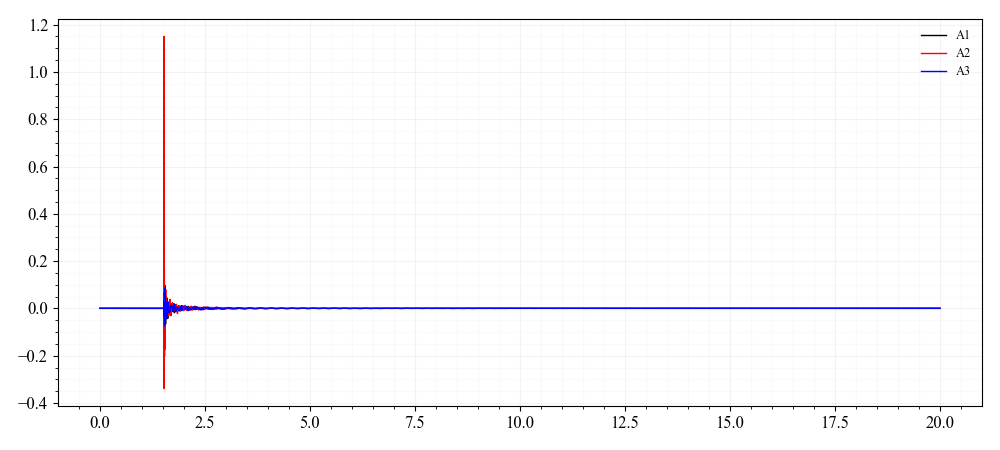

In [7]:
plt.figure(figsize=(10, 4.5), dpi = 100)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.plot(Time, A1, '-', alpha=1, linewidth=1, color='k', label = 'A1')
plt.plot(Time, A2, '-', alpha=1, linewidth=1, color='red', label = 'A2')
plt.plot(Time, A3, '-', alpha=1, linewidth=1, color='blue', label = 'A3')

#plt.xlim(1.5,2)

plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
#plt.savefig('Graf_FFT.jpg', dpi=800)
plt.show()

In [8]:
# quitar offset
base = signal.detrend(base, type='constant')
A1 = signal.detrend(A1, type='constant')
A2 = signal.detrend(A2, type='constant')
A3 = signal.detrend(A3, type='constant')

In [9]:
# -------------------------
# 4. Filtrado
# -------------------------
fc = 40.0
b, a = signal.butter(4, fc/(fs/2), btype='low') #Frecuencia de Nyquist fs/2

base_f = signal.filtfilt(b, a, base)
A1_f   = signal.filtfilt(b, a, A1)
A2_f   = signal.filtfilt(b, a, A2)
A3_f   = signal.filtfilt(b, a, A3)

In [10]:
# -------------------------
# 5. PSD y FRF
# -------------------------
# PSD cuánta energía tiene la señal en cada frecuencia

nseg = 16384 #resolución espectral (grande)

f, Sxx = welch(base_f, fs=fs, nperseg=nseg) #Esto calcula la densidad espectral de potencia de la señal base
f, Syy = welch(A1_f,  fs=fs, nperseg=nseg) #Esto calcula la densidad espectral de potencia de la señal salida

f, Syx = csd(A1_f, base_f, fs=fs, nperseg=nseg) #Aquí se calcula el Cross Spectral Density, permite ver cómo la entrada excita la salida en frecuencia
f, coh = coherence(A1_f, base_f, fs=fs, nperseg=nseg) #Mide qué tan confiable es la relación entrada → salida

T = np.sqrt(Syy/Sxx)       # transmisibilidad (cuánto de la vibración de la base llega al punto medido.)
H1 = Syx/Sxx               # FRF (Frequency Response Function)

Frecuencias candidatas [Hz]:
[ 3.87499995 13.9999998  14.4999998  19.99999972 20.49999971]


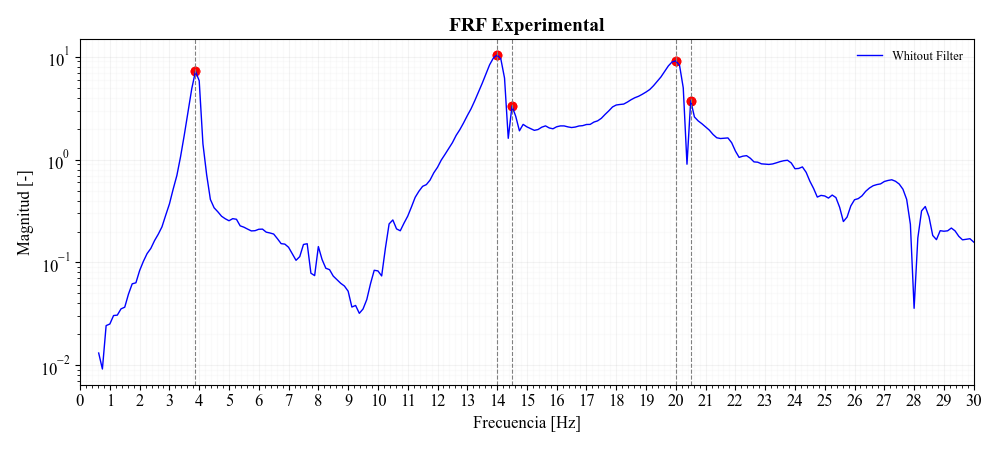

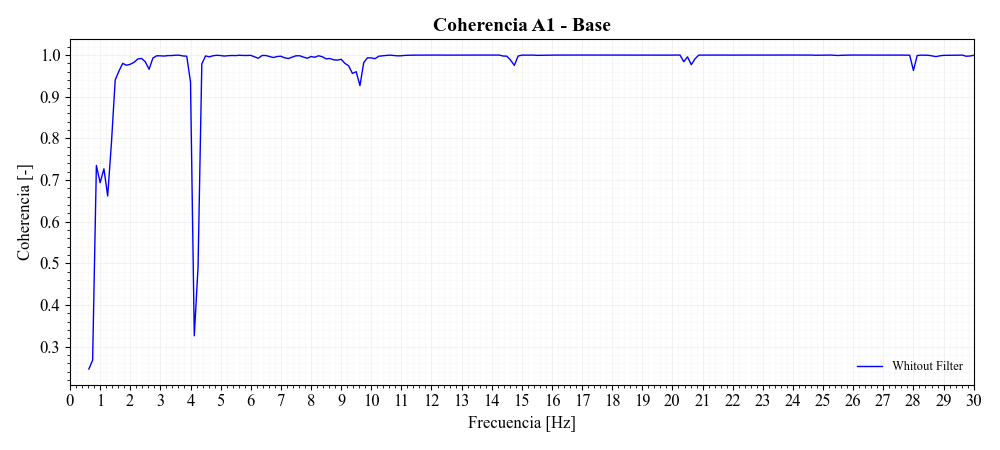

In [11]:
# -------------------------
# 6. Buscar picos
# -------------------------
mask = (f >= 0.5) & (f <= 30)

peaks, props = find_peaks(np.abs(H1[mask]), prominence=np.max(np.abs(H1[mask]))*0.05)
freq_peaks = f[mask][peaks]

print("Frecuencias candidatas [Hz]:")
print(freq_peaks)

# -------------------------
# 7. Gráficos
# -------------------------
plt.figure(figsize=(10, 4.5), dpi = 100)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.title('FRF Experimental', fontsize=14, fontweight='bold') 
plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('Magnitud [-]', fontsize=12)

plt.plot(f[mask], np.abs(H1[mask]), '-', alpha=1, linewidth=1, color='blue', label = 'Whitout Filter')
plt.scatter(freq_peaks, np.abs(H1[mask])[peaks], color='r')

plt.scatter(freq_peaks, np.abs(H1[mask])[peaks], color='r')

for i in range(0, len(freq_peaks)):
    plt.axvline(freq_peaks[i], color='gray', linestyle='--', linewidth=0.8)

#plt.margins(y=0.1)

plt.xlim(0,30)
major_ticks_top=np.linspace(0,30,31)
plt.xticks(major_ticks_top)
plt.yscale('log')
plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
#plt.savefig('Graf_FFT.jpg', dpi=800)
plt.show()


plt.figure(figsize=(10, 4.5), dpi = 100)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.title('Coherencia A1 - Base', fontsize=14, fontweight='bold') 
plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('Coherencia [-]', fontsize=12)

plt.plot(f[mask], coh[mask], '-', alpha=1, linewidth=1, color='blue', label = 'Whitout Filter')

#plt.margins(y=0.1)

plt.xlim(0,30)
major_ticks_top=np.linspace(0,30,31)
plt.xticks(major_ticks_top)
    
plt.legend(loc=4, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
#plt.savefig('Graf_FFT.jpg', dpi=800)
plt.show()

In [12]:
x = np.array(df[list(df)[0]])
y1 = np.array(df[list(df)[1]])
y2 = np.array(df[list(df)[2]])
y3 = np.array(df[list(df)[3]])
y4 = np.array(df[list(df)[4]])

In [13]:
#Filtrar Datos
F = 2048
fcut = 20; #frecuencia de corte para el filtro pasa baja
b, a = signal.butter(10, fcut/(F/2), 'low')

y1_filt = np.array(signal.filtfilt(b,a,df[list(df)[1]]))
y2_filt = np.array(signal.filtfilt(b,a,df[list(df)[2]]))
y3_filt = np.array(signal.filtfilt(b,a,df[list(df)[3]]))
y4_filt = np.array(signal.filtfilt(b,a,df[list(df)[4]]))

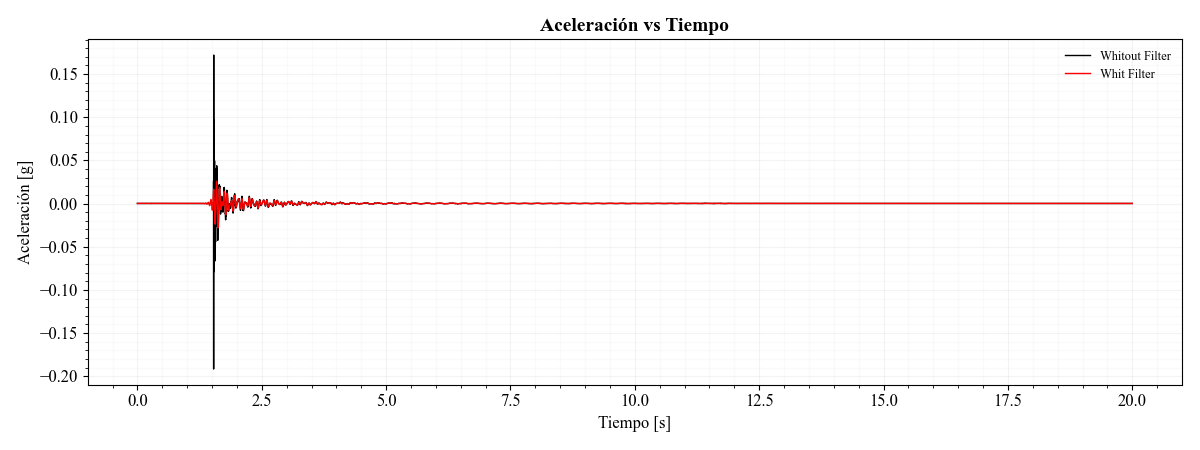

In [14]:
plt.figure(figsize=(12, 4.5), dpi = 100)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.title('Aceleración vs Tiempo', fontsize=14, fontweight='bold') 
plt.xlabel('Tiempo [s]', fontsize=12)
plt.ylabel('Aceleración [g]', fontsize=12)

plt.plot(x, y1, alpha=1, linewidth=1, color='k', label = 'Whitout Filter')
plt.plot(x, y1_filt, alpha=1, linewidth=1, color='red', label = 'Whit Filter')

#plt.margins(y=0.1)

#plt.ylim(0,130000)
# major_ticks_top=np.linspace(0,2.5,6)
# plt.yticks(major_ticks_top)
    
plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
#plt.savefig('Graf_Accel.jpg', dpi=800)
plt.show()

In [15]:
# Transformada Rapida de Fourier (FFT)

f = 2048
T = 1.0 / f
N = len(x)

x_f = np.linspace(0.0, 1.0/(2.0*T), N//2)  
x_ff = x_f[1:int(max(x_f))]

#Crear vectores 
y1_FFT = np.abs(scipy.fft.fft(y1))[1:int(max(x_f))]
y1_filt_FFT = np.abs(scipy.fft.fft(y1_filt))[1:int(max(x_f))]

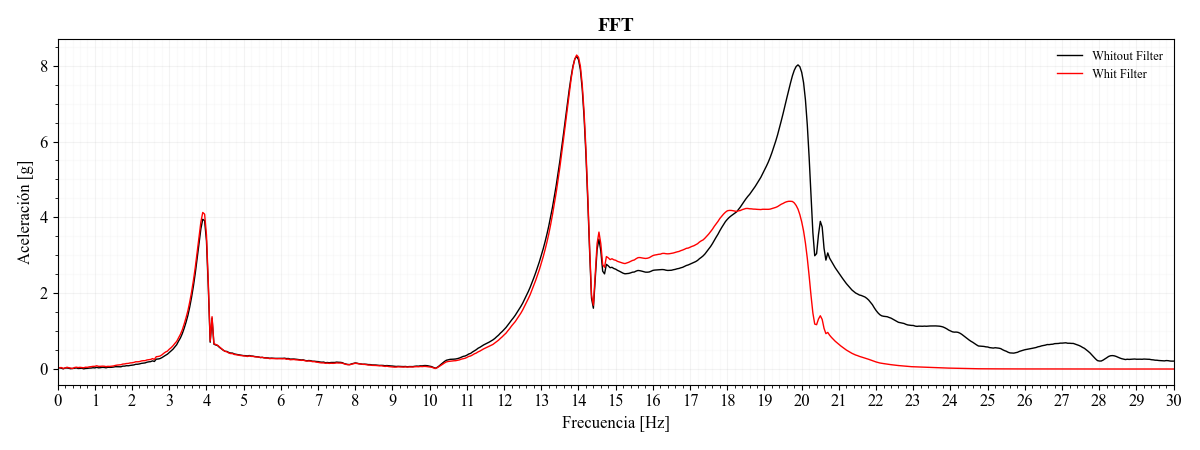

In [16]:
plt.figure(figsize=(12, 4.5), dpi = 100)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.title('FFT', fontsize=14, fontweight='bold') 
plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('Aceleración [g]', fontsize=12)

plt.plot(x_ff, y1_FFT, '-', alpha=1, linewidth=1, color='k', label = 'Whitout Filter')
plt.plot(x_ff, y1_filt_FFT, '-', alpha=1, linewidth=1, color='red', label = 'Whit Filter')

#plt.margins(y=0.1)

plt.xlim(0,30)
major_ticks_top=np.linspace(0,30,31)
plt.xticks(major_ticks_top)
    
plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
#plt.savefig('Graf_FFT.jpg', dpi=800)
plt.show()

In [17]:
mask = (x_ff >= 0) & (x_ff <= 5)

y_rango = y1_FFT[mask]
x_rango = x_ff[mask]
idx_local = np.argmax(y_rango) # índice del máximo en el tramo analizado
f_pico = x_rango[idx_local]; y_pico = y_rango[idx_local]

print(f"Frecuencia Fundamental:\t{f_pico:.4f} [Hz]:")
print(f"Periodo Fundamental:\t{1/f_pico:.4f} [s]:")

Frecuencia Fundamental:	3.9002 [Hz]:
Periodo Fundamental:	0.2564 [s]:


In [18]:
mask = (x_ff >= 13) & (x_ff <= 14)

y_rango = y1_FFT[mask]
x_rango = x_ff[mask]
idx_local = np.argmax(y_rango) # índice del máximo en el tramo analizado
f_pico = x_rango[idx_local]; y_pico = y_rango[idx_local]

print(f"Frecuencia Fundamental:\t{f_pico:.4f} [Hz]:")
print(f"Periodo Fundamental:\t{1/f_pico:.4f} [s]:")

Frecuencia Fundamental:	13.9507 [Hz]:
Periodo Fundamental:	0.0717 [s]:


In [19]:
# + Masa ---> + Flexible ----> - Frecuencia
# + Rigidez ---> + Rigido ----> + Frecuencia



In [20]:
import pandas as pd
import numpy as np

df = pd.read_table('./Registros/{}'.format(enss), skiprows=22, decimal=",")
df.columns = ['Tiempo [s]', 'S1', 'S2', 'S3', 'Hammer', 'Comment']
df.drop(['Comment'], axis=1, inplace=True)
display(df)

,Tiempo [s],S1,S2,S3,Hammer
0,0.000000,0.000179,0.000238,0.000227,0.000167
1,0.000488,0.000189,0.000314,0.000241,0.000106
2,0.000977,0.000146,0.000283,0.000228,0.000171
3,0.001465,0.000131,0.000301,0.000255,0.000177
4,0.001953,0.000176,0.000285,0.000218,0.000162
...,...,...,...,...,...
40955,19.997559,0.000154,0.000279,0.000255,0.000154
40956,19.998047,0.000138,0.000253,0.000236,0.000158
40957,19.998535,0.000157,0.000287,0.000252,0.000139
40958,19.999023,0.000172,0.000255,0.000243,0.000227


In [21]:
#Crear los vectores
t = df['Tiempo [s]'].values
s1 = df['S1'].values
s2 = df['S2'].values
s3 = df['S3'].values

In [22]:
#Calcular frecuencia de muestreo
dt = np.mean(np.diff(t))
fs = 1/dt
print(fs)

2047.9999711992973


In [23]:
#Remover offset (MUY importante)
s1 = s1 - np.mean(s1)
s2 = s2 - np.mean(s2)
s3 = s3 - np.mean(s3)

In [24]:
#Filtrado
from scipy import signal

fc = 20
b,a = signal.butter(4, fc/(fs/2), 'low')

s1_f = signal.filtfilt(b,a,s1)
s2_f = signal.filtfilt(b,a,s2)
s3_f = signal.filtfilt(b,a,s3)

In [25]:
#FFT correcta
from scipy.fft import rfft, rfftfreq

N = len(t)

freq = rfftfreq(N, d=dt)

S1 = np.abs(rfft(s1))
S1f = np.abs(rfft(s1_f))

S2 = np.abs(rfft(s2))
S3 = np.abs(rfft(s3))

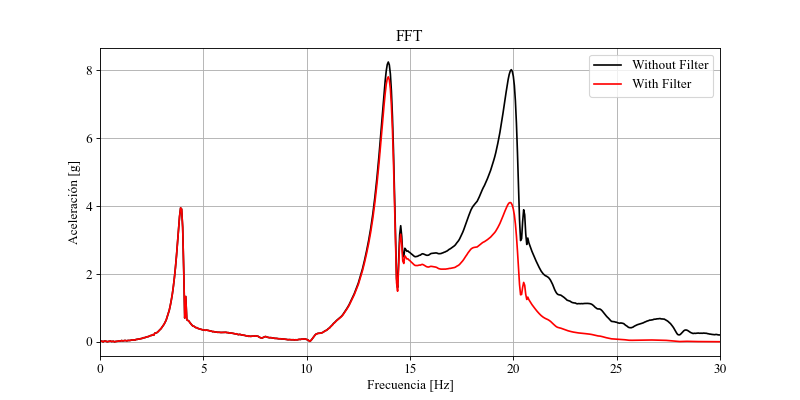

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(freq,S1,label='Without Filter',color='black')
plt.plot(freq,S1f,label='With Filter',color='red')

plt.xlim(0,30)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Aceleración [g]')
plt.title('FFT')

plt.legend()
plt.grid()

plt.show()

In [27]:
from scipy.signal import find_peaks
peaks,_ = find_peaks(S1f,height=5)
freq_peaks = freq[peaks]
print(freq_peaks)

[13.9499998]


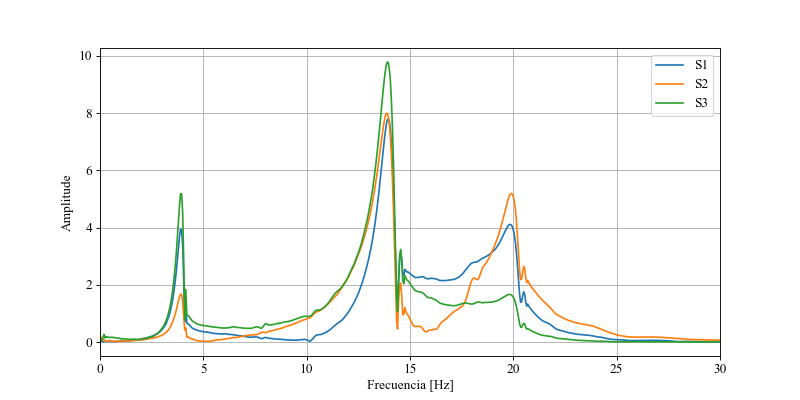

In [28]:
plt.figure(figsize=(10,5))

plt.plot(freq,np.abs(rfft(s1_f)),label='S1')
plt.plot(freq,np.abs(rfft(s2_f)),label='S2')
plt.plot(freq,np.abs(rfft(s3_f)),label='S3')

plt.xlim(0,30)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitude')

plt.legend()
plt.grid()

plt.show()

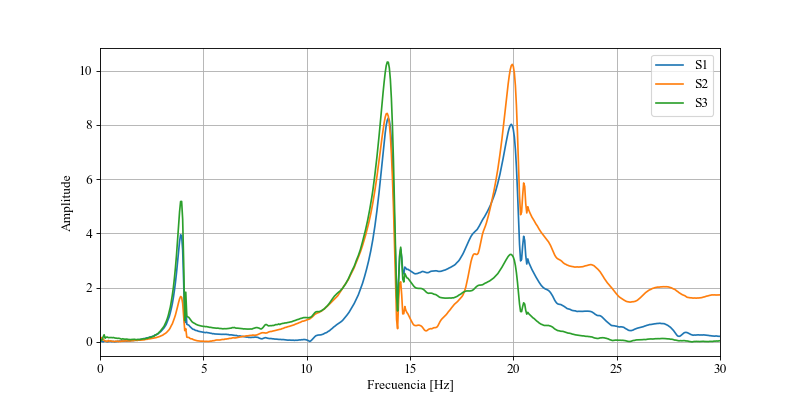

In [29]:
plt.figure(figsize=(10,5))

plt.plot(freq,S1,label='S1')
plt.plot(freq,S2,label='S2')
plt.plot(freq,S3,label='S3')

plt.xlim(0,30)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitude')

plt.legend()
plt.grid()

plt.show()

In [30]:
mask = (freq >= 0) & (freq <= 5)

y_rango = np.abs(rfft(s1_f))[mask]
x_rango = freq[mask]
idx_local = np.argmax(y_rango) # índice del máximo en el tramo analizado
f_pico = x_rango[idx_local]; y_pico = y_rango[idx_local]

print(f"Frecuencia Fundamental:\t{f_pico:.4f} [Hz]:")
print(f"Periodo Fundamental:\t{1/f_pico:.4f} [s]:")

Frecuencia Fundamental:	3.9000 [Hz]:
Periodo Fundamental:	0.2564 [s]:
